# Career Prediction Engine — Dataset Preprocessing

**Project:** Integrated Future & Career Prediction Engine  
**Feature set:** Reduced to 15 features (supervisor requirement)  
**Outputs:**
- `saved_objects/*.pkl` — model-ready splits, scaler, feature column list
- `plots/correlation_matrix.png` — feature correlation heatmap

## Setup — Imports, Feature Domains & Paths

All 15 features are declared once in `FEATURE_DOMAINS`. Everything downstream
reads from that dict — no column names are hardcoded anywhere else.

In [20]:
%matplotlib inline

import sys
import random
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

FEATURE_DOMAINS = {
    'academic'  : [
        'gpa_cumulative', 'gpa_trend', 'assignment_completion_rate',
        'late_submission_rate', 'resit_count', 'project_performance'
    ],
    'behavioral': [
        'attendance_rate', 'weekly_study_hours', 'sleep_hours_avg',
        'sleep_consistency', 'part_time_work_hours'
    ],
    'emotional' : ['stress_level', 'anxiety_score', 'mood_stability'],
    'career'    : ['career_clarity_score']
}
FEATURE_COLUMNS = [col for cols in FEATURE_DOMAINS.values() for col in cols]
RISK_MAP   = {'Low': 0, 'Medium': 1, 'High': 2}
RISK_NAMES = {v: k for k, v in RISK_MAP.items()}

# VS Code Jupyter sets CWD to the notebook's own directory
NOTEBOOK_DIR = Path.cwd()
BACKEND_DIR  = NOTEBOOK_DIR.parents[1]
DATASET_CSV  = BACKEND_DIR / 'datasets' / 'career-prediction-engine' / 'student_dataset.csv'
DATASET_XLS  = DATASET_CSV.parent / 'student_dataset.xls'
SAVED_DIR    = BACKEND_DIR / 'trained-models' / 'career-prediction-engine' / 'saved_objects'
PLOTS_DIR    = BACKEND_DIR / 'trained-models' / 'career-prediction-engine' / 'plots'
CLEANED_CSV  = DATASET_CSV.parent / 'student_dataset_cleaned.csv'

SAVED_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Features     : {len(FEATURE_COLUMNS)}')
print(f'Saved to     : {SAVED_DIR}')
print(f'Plots to     : {PLOTS_DIR}')
print(f'Dataset CSV  : {DATASET_CSV.exists()}')
print(f'Dataset XLS  : {DATASET_XLS.exists()}')
print(f'Cleaned CSV  : {CLEANED_CSV}')

Features     : 15
Saved to     : d:\R26-IT-153\backend\trained-models\career-prediction-engine\saved_objects
Plots to     : d:\R26-IT-153\backend\trained-models\career-prediction-engine\plots
Dataset CSV  : True
Dataset XLS  : False
Cleaned CSV  : d:\R26-IT-153\backend\datasets\career-prediction-engine\student_dataset_cleaned.csv


## Step 1 — Load Dataset

We try CSV first (canonical format), then fall back to XLS if the CSV is absent.
Printing the shape immediately confirms the file was read correctly.

In [21]:
if DATASET_CSV.exists():
    raw = pd.read_csv(DATASET_CSV)
    print(f'Loaded CSV : {DATASET_CSV}')
elif DATASET_XLS.exists():
    raw = pd.read_excel(DATASET_XLS)
    print(f'Loaded XLS : {DATASET_XLS}')
else:
    raise FileNotFoundError(f'Neither dataset CSV nor XLS found: {DATASET_CSV}, {DATASET_XLS}')

print(f'Raw shape  : {raw.shape}')
print(f'Columns ({len(raw.columns)}): {raw.columns.tolist()}')

print(raw.head())


Loaded CSV : d:\R26-IT-153\backend\datasets\career-prediction-engine\student_dataset.csv
Raw shape  : (10000, 29)
Columns (29): ['student_id', 'gpa_cumulative', 'gpa_trend', 'module_avg_score', 'module_score_variance', 'project_performance', 'assignment_completion_rate', 'late_submission_rate', 'resit_count', 'lms_login_frequency', 'weekly_study_hours', 'attendance_rate', 'sleep_hours_avg', 'sleep_consistency', 'extracurricular_hours', 'part_time_work_hours', 'library_resource_usage', 'peer_collaboration_score', 'help_seeking_behavior', 'screen_time_non_study', 'stress_level', 'anxiety_score', 'mood_stability', 'motivation_score', 'social_support_score', 'sense_of_belonging', 'career_clarity_score', 'career_readiness_score', 'burnout_risk_level']
  student_id  gpa_cumulative  gpa_trend  module_avg_score  \
0     S00001            3.65      -0.43                83   
1     S00002            3.48      -0.17                84   
2     S00003            3.45      -0.14                75   

## Step 2 — Select 15 Features + Regression Target

Instead of dropping named columns, we **select** only what we need.
This is more robust: if new columns are added to the raw file in future,
they are automatically ignored without any code changes.

In [22]:
keep_cols = FEATURE_COLUMNS + ['career_readiness_score']

missing_in_raw = [c for c in keep_cols if c not in raw.columns]
if missing_in_raw:
    raise KeyError(f'Required columns missing from dataset: {missing_in_raw}')

df      = raw[keep_cols].copy()
dropped = [c for c in raw.columns if c not in keep_cols]

print(f'Features kept    : {len(FEATURE_COLUMNS)}')
print(f'Columns dropped ({len(dropped)}): {dropped}')
print(f'Working shape    : {df.shape}')
display(df.head())

Features kept    : 15
Columns dropped (13): ['student_id', 'module_avg_score', 'module_score_variance', 'lms_login_frequency', 'extracurricular_hours', 'library_resource_usage', 'peer_collaboration_score', 'help_seeking_behavior', 'screen_time_non_study', 'motivation_score', 'social_support_score', 'sense_of_belonging', 'burnout_risk_level']
Working shape    : (10000, 16)


,gpa_cumulative,gpa_trend,assignment_completion_rate,late_submission_rate,resit_count,project_performance,attendance_rate,weekly_study_hours,sleep_hours_avg,sleep_consistency,part_time_work_hours,stress_level,anxiety_score,mood_stability,career_clarity_score,career_readiness_score
0,3.65,-0.43,0.68,0.28,1,85,0.68,39,5.5,1.20,18,40,11,48,61,72.5
1,3.48,-0.17,0.87,0.22,0,77,0.65,31,6.1,0.93,26,31,11,37,56,70.8
2,3.45,-0.14,0.72,0.35,1,83,0.76,34,5.6,1.60,0,50,12,55,33,62.8
3,4.00,0.15,0.82,0.34,0,89,0.86,47,5.5,1.93,32,68,16,72,66,79.8
4,3.25,0.54,0.99,0.15,0,82,0.68,15,5.4,1.55,18,33,10,39,22,59.9


## Step 3 — Derive Academic Risk Level (Classification Target)

The raw dataset does not contain an academic risk label.
We construct it using a **rule-based scoring function** agreed with the supervisor.
Five indicators contribute weighted points; the total maps to Low / Medium / High.

**Noise injection (supervisor feedback fix):** 12 % of borderline students (score 3–6)
receive a random ±2 point shift (`random.seed(42)` for reproducibility). This breaks
the perfect circular relationship between the scoring rules and the feature matrix,
preventing the model from trivially reverse-engineering the labels and inflating accuracy.

In [23]:
random.seed(42)


def derive_academic_risk(row):
    score = 0
    if row['gpa_cumulative'] < 2.5:               score += 3
    elif row['gpa_cumulative'] < 3.0:             score += 2
    elif row['gpa_cumulative'] < 3.3:             score += 1
    if row['gpa_trend'] < -0.3:                   score += 2
    elif row['gpa_trend'] < 0:                    score += 1
    if row['resit_count'] >= 2:                   score += 3
    elif row['resit_count'] == 1:                 score += 1
    if row['attendance_rate'] < 0.6:              score += 2
    elif row['attendance_rate'] < 0.75:           score += 1
    if row['assignment_completion_rate'] < 0.5:   score += 2
    elif row['assignment_completion_rate'] < 0.7: score += 1
    # Inject 12% noise on borderline scores (3–6 range)
    # Simulates real-world uncertainty; breaks perfect rule reconstruction
    if 3 <= score <= 6:
        if random.random() < 0.12:
            score += random.choice([-2, 2])
    if score >= 7:   return 'High'
    elif score >= 4: return 'Medium'
    else:            return 'Low'


df['academic_risk_level'] = df.apply(derive_academic_risk, axis=1)

risk_dist = df['academic_risk_level'].value_counts()
print('Academic risk distribution:')
display(risk_dist.to_frame())
print(f'Shape after derivation: {df.shape}')

Academic risk distribution:


,count
academic_risk_level,
Low,7244
Medium,2143
High,613


Shape after derivation: (10000, 17)


## Step 4 — Missing Value Check

Missing values must be handled before scaling, as `StandardScaler` will propagate
NaNs silently. We fill numeric columns with their median (robust to outliers).
Non-numeric columns with nulls would indicate a data-quality problem and are flagged.

In [24]:
check_cols    = FEATURE_COLUMNS + ['career_readiness_score']
missing_count = df[check_cols].isnull().sum()
missing_cols  = missing_count[missing_count > 0]

if missing_cols.empty:
    print('No missing values — dataset is clean.')
else:
    print(f'Missing values detected in {len(missing_cols)} column(s):')
    for col, cnt in missing_cols.items():
        pct = cnt / len(df) * 100
        if df[col].dtype in ['float64', 'int64']:
            med = df[col].median()
            df[col] = df[col].fillna(med)
            print(f'  {col!r}: {cnt} nulls ({pct:.1f}%) → filled with median ({med:.4f})')
        else:
            print(f'  WARNING: {col!r} is non-numeric with {cnt} nulls.')

No missing values — dataset is clean.


## Step 5 — Encode Academic Risk Level

Classifiers require numeric targets. We use **ordinal encoding** (Low=0, Medium=1,
High=2) which preserves the natural severity ordering — important for models that
can exploit ordinal structure (e.g., gradient-boosted trees).

In [25]:
df['academic_risk_encoded'] = df['academic_risk_level'].map(RISK_MAP)

print(f'Encoding: {RISK_MAP}')
display(
    df[['academic_risk_level', 'academic_risk_encoded']]
    .value_counts()
    .reset_index()
    .rename(columns={0: 'count'})
)

Encoding: {'Low': 0, 'Medium': 1, 'High': 2}


,academic_risk_level,academic_risk_encoded,count
0,Low,0,7244
1,Medium,1,2143
2,High,2,613


## Step 6 — Separate Features and Targets

We build **X** from exactly the 15 columns in `FEATURE_COLUMNS`.
Any non-numeric column in X would cause `StandardScaler` to fail — we check
for this explicitly and raise a descriptive error rather than letting it crash later.

In [26]:
X        = df[FEATURE_COLUMNS].copy()
y_risk   = df['academic_risk_encoded']
y_career = df['career_readiness_score']

career_range = f"[{y_career.min():.2f}, {y_career.max():.2f}]"
print(f'Feature matrix X : {X.shape}')
print(f'Risk target      : {y_risk.shape}  — classes {sorted(y_risk.unique())}')
print(f'Career target    : {y_career.shape} — range {career_range}')

non_numeric = X.select_dtypes(exclude='number').columns.tolist()
if non_numeric:
    raise ValueError(
        'Non-numeric columns found in X — cannot scale.\n'
        f'Columns: {non_numeric}'
    )
print('All 15 feature columns are numeric — safe to scale.')
display(X.describe())

Feature matrix X : (10000, 15)
Risk target      : (10000,)  — classes [0, 1, 2]
Career target    : (10000,) — range [39.10, 91.70]
All 15 feature columns are numeric — safe to scale.


,gpa_cumulative,gpa_trend,assignment_completion_rate,late_submission_rate,resit_count,project_performance,attendance_rate,weekly_study_hours,sleep_hours_avg,sleep_consistency,part_time_work_hours,stress_level,anxiety_score,mood_stability,career_clarity_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.481330,0.099449,0.797490,0.203706,0.592900,79.401600,0.697956,29.303000,5.498360,1.171970,14.804900,37.677900,9.522000,39.501900,54.186300
std,0.349093,0.282169,0.129103,0.129618,0.806123,8.251153,0.116570,11.696669,0.638799,0.540688,9.389838,20.183272,4.381739,16.469831,16.990081
min,2.040000,-0.940000,0.500000,0.000000,0.000000,50.000000,0.260000,0.000000,3.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.240000,-0.090000,0.710000,0.100000,0.000000,74.000000,0.620000,21.000000,5.100000,0.800000,8.000000,24.000000,6.000000,28.000000,42.750000
50%,3.500000,0.100000,0.800000,0.200000,0.000000,80.000000,0.700000,29.000000,5.500000,1.170000,14.000000,37.000000,9.000000,39.000000,54.000000
75%,3.760000,0.290000,0.900000,0.300000,1.000000,85.000000,0.780000,37.000000,5.900000,1.540000,21.000000,51.000000,13.000000,51.000000,66.000000
max,4.000000,1.000000,1.000000,0.500000,5.000000,95.000000,1.000000,68.000000,7.900000,3.150000,40.000000,100.000000,21.000000,91.000000,100.000000


## Step 7 — Correlation Analysis

With 15 features, annotating each cell is readable. We flag pairs with |r| > 0.85
as a multicollinearity warning — highly correlated features add noise without new
information and can inflate variance in linear models.

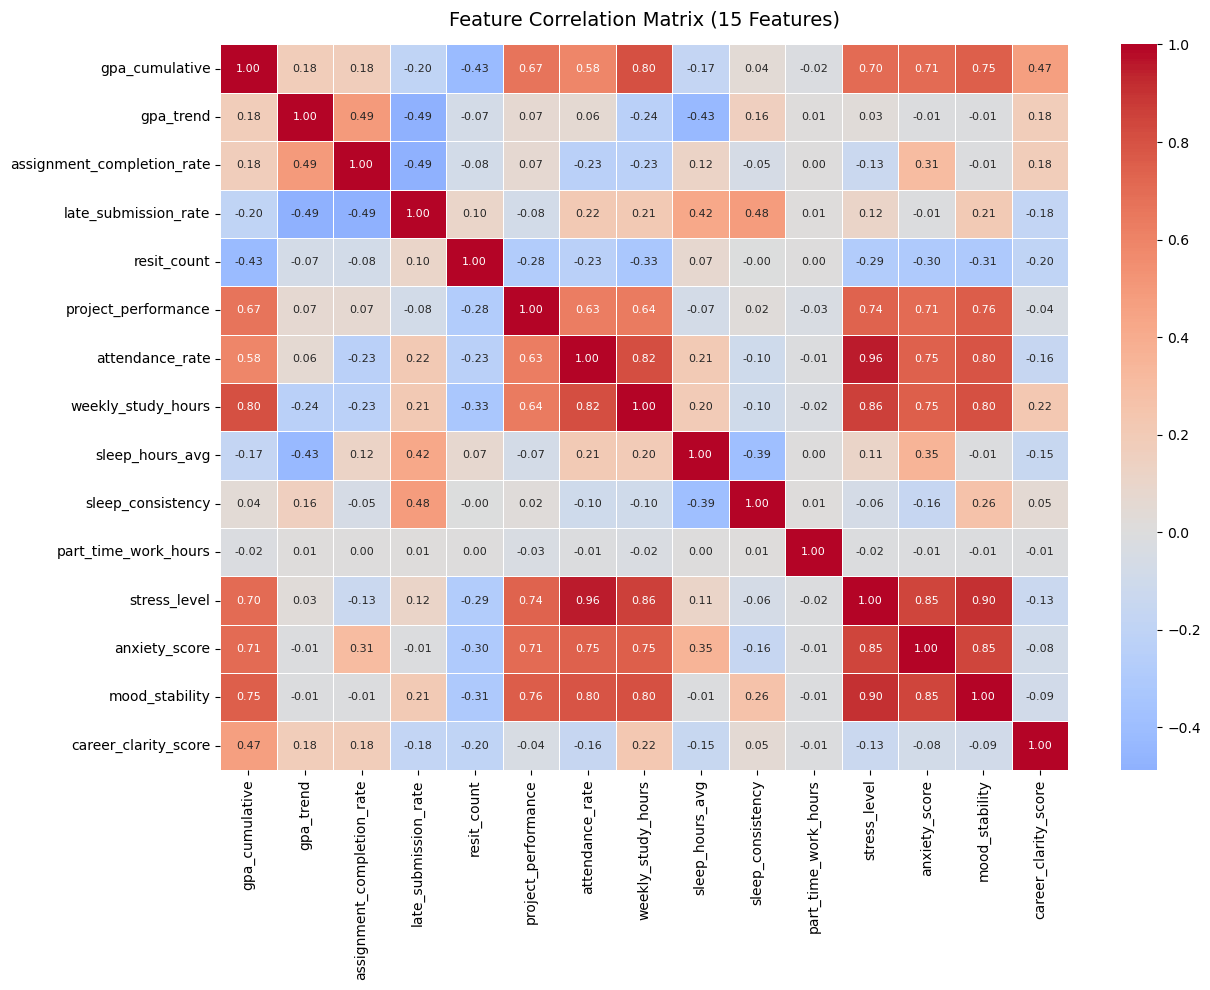

Saved: d:\R26-IT-153\backend\trained-models\career-prediction-engine\plots\correlation_matrix.png

WARNING — Highly correlated pairs (|r| > 0.85):
  attendance_rate  <->  stress_level  :  0.957
  weekly_study_hours  <->  stress_level  :  0.863
  stress_level  <->  mood_stability  :  0.905


In [27]:
corr_matrix = X.corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Matrix (15 Features)', fontsize=14, pad=14)
plt.tight_layout()
corr_path = PLOTS_DIR / 'correlation_matrix.png'
plt.savefig(corr_path, dpi=150)
plt.show()
print(f'Saved: {corr_path}')

cols = corr_matrix.columns.tolist()
high_corr = []
for i, col_i in enumerate(cols):
    for col_j in cols[i + 1:]:
        val = abs(corr_matrix.loc[col_i, col_j])
        if val > 0.85:
            high_corr.append((col_i, col_j, round(val, 3)))

if high_corr:
    print('\nWARNING — Highly correlated pairs (|r| > 0.85):')
    for f1, f2, v in high_corr:
        print(f'  {f1}  <->  {f2}  :  {v}')
else:
    print('\nNo highly correlated pairs (all |r| < 0.85).')

## Step 8 — Train/Test Split & Feature Scaling

**Why stratify the risk split?** — Without `stratify=y_risk`, a random 80/20 cut
could put almost all 'High' risk examples in one split, making evaluation misleading.

**Why fit the scaler only on the training set?** — If we fit on the full dataset,
test-set statistics leak into the scaler's mean/std, giving an unrealistically
optimistic evaluation. Fit on train; transform both.

In [28]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_risk, test_size=0.2, random_state=42, stratify=y_risk
)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_career, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_r_scaled = pd.DataFrame(scaler.fit_transform(X_train_r), columns=FEATURE_COLUMNS)
X_test_r_scaled  = pd.DataFrame(scaler.transform(X_test_r),      columns=FEATURE_COLUMNS)
X_train_c_scaled = pd.DataFrame(scaler.transform(X_train_c),     columns=FEATURE_COLUMNS)
X_test_c_scaled  = pd.DataFrame(scaler.transform(X_test_c),      columns=FEATURE_COLUMNS)

print(f'Risk   — train: {X_train_r_scaled.shape}  |  test: {X_test_r_scaled.shape}')
print(f'Career — train: {X_train_c_scaled.shape} |  test: {X_test_c_scaled.shape}')
display(X_train_r_scaled.describe().round(3))

Risk   — train: (8000, 15)  |  test: (2000, 15)
Career — train: (8000, 15) |  test: (2000, 15)


,gpa_cumulative,gpa_trend,assignment_completion_rate,late_submission_rate,resit_count,project_performance,attendance_rate,weekly_study_hours,sleep_hours_avg,sleep_consistency,part_time_work_hours,stress_level,anxiety_score,mood_stability,career_clarity_score
count,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000
mean,0.000,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-4.140,-3.701,-2.310,-1.571,-0.737,-3.564,-3.672,-2.510,-3.611,-2.162,-1.569,-1.864,-2.172,-2.396,-3.196
25%,-0.690,-0.678,-0.679,-0.722,-0.737,-0.653,-0.670,-0.709,-0.626,-0.684,-0.718,-0.676,-0.802,-0.695,-0.717
50%,0.058,-0.002,0.020,-0.027,-0.737,0.075,0.017,-0.023,0.002,-0.001,-0.079,-0.032,-0.117,-0.027,-0.009
75%,0.777,0.674,0.797,0.745,0.507,0.681,0.703,0.664,0.631,0.683,0.666,0.661,0.796,0.701,0.699
max,1.496,3.200,1.574,2.288,4.237,1.894,2.590,3.322,3.773,3.658,2.689,3.086,2.623,3.130,2.706


## Step 9 — SMOTE: Fix Class Imbalance

**Why SMOTE?** — If Low-risk students dominate the training set, the classifier
will learn to predict 'Low' for everything and still report decent accuracy.
SMOTE generates synthetic minority-class samples by interpolating in feature space,
avoiding information loss (under-sampling) and memorisation (duplicate over-sampling).

**Applied only to the training set** — the test set must reflect real-world class
distributions so evaluation is honest.

In [29]:
before_counts = pd.Series(y_train_r.values).value_counts().sort_index()
print('Before SMOTE:')
display(
    before_counts.rename(index=RISK_NAMES).rename('count').to_frame()
)

smote = SMOTE(random_state=42)
X_train_r_balanced, y_train_r_balanced = smote.fit_resample(X_train_r_scaled, y_train_r)

after_counts = pd.Series(y_train_r_balanced).value_counts().sort_index()
print('After SMOTE:')
display(
    after_counts.rename(index=RISK_NAMES).rename('count').to_frame()
)
print('All three classes are now balanced.')

Before SMOTE:


,count
Low,5795
Medium,1714
High,491


After SMOTE:


,count
academic_risk_encoded,
Low,5795
Medium,5795
High,5795


All three classes are now balanced.


## Step 10 — Save All Preprocessed Objects

Each object is saved and immediately **reloaded** to verify the file is readable
and not corrupted. This catches disk-full, permission, and serialisation errors
before they cause a silent failure downstream in model training.

In [30]:
save_targets = {
    'scaler.pkl'          : scaler,
    'feature_columns.pkl' : FEATURE_COLUMNS,
    'risk_train.pkl'      : (X_train_r_balanced, y_train_r_balanced),
    'risk_test.pkl'       : (X_test_r_scaled,    y_test_r),
    'career_train.pkl'    : (X_train_c_scaled,   y_train_c),
    'career_test.pkl'     : (X_test_c_scaled,    y_test_c),
}

print(f'Saving to: {SAVED_DIR}\n')
for filename, obj in save_targets.items():
    path = SAVED_DIR / filename
    joblib.dump(obj, path)
    loaded = joblib.load(path)
    if isinstance(loaded, tuple):
        parts = ', '.join(
            str(o.shape) if hasattr(o, 'shape') else f'len={len(o)}'
            for o in loaded
        )
        print(f'  checkmark  {filename:<26} verified  ({parts})')
    elif isinstance(loaded, list):
        print(f'  checkmark  {filename:<26} verified  ({len(loaded)} feature names)')
    else:
        print(f'  checkmark  {filename:<26} verified  ({type(loaded).__name__})')

Saving to: d:\R26-IT-153\backend\trained-models\career-prediction-engine\saved_objects

  checkmark  scaler.pkl                 verified  (StandardScaler)
  checkmark  feature_columns.pkl        verified  (15 feature names)
  checkmark  risk_train.pkl             verified  ((17385, 15), (17385,))
  checkmark  risk_test.pkl              verified  ((2000, 15), (2000,))
  checkmark  career_train.pkl           verified  ((8000, 15), (8000,))
  checkmark  career_test.pkl            verified  ((2000, 15), (2000,))


## Save Cleaned Dataset as CSV

Save the fully preprocessed `df` (15 features + `career_readiness_score` +
`academic_risk_level` + `academic_risk_encoded`) to the datasets folder.
This gives a portable, human-readable snapshot of the cleaned data before
the train/test split — useful for auditing, sharing, and future model runs.

In [31]:
df.to_csv(CLEANED_CSV, index=False)
print(f'Saved   : {CLEANED_CSV}')
print(f'Shape   : {df.shape}  ({len(df):,} rows × {df.shape[1]} columns)')
print(f'Columns : {df.columns.tolist()}')
display(df.head())

Saved   : d:\R26-IT-153\backend\datasets\career-prediction-engine\student_dataset_cleaned.csv
Shape   : (10000, 18)  (10,000 rows × 18 columns)
Columns : ['gpa_cumulative', 'gpa_trend', 'assignment_completion_rate', 'late_submission_rate', 'resit_count', 'project_performance', 'attendance_rate', 'weekly_study_hours', 'sleep_hours_avg', 'sleep_consistency', 'part_time_work_hours', 'stress_level', 'anxiety_score', 'mood_stability', 'career_clarity_score', 'career_readiness_score', 'academic_risk_level', 'academic_risk_encoded']


,gpa_cumulative,gpa_trend,assignment_completion_rate,late_submission_rate,resit_count,project_performance,attendance_rate,weekly_study_hours,sleep_hours_avg,sleep_consistency,part_time_work_hours,stress_level,anxiety_score,mood_stability,career_clarity_score,career_readiness_score,academic_risk_level,academic_risk_encoded
0,3.65,-0.43,0.68,0.28,1,85,0.68,39,5.5,1.20,18,40,11,48,61,72.5,Medium,1
1,3.48,-0.17,0.87,0.22,0,77,0.65,31,6.1,0.93,26,31,11,37,56,70.8,Low,0
2,3.45,-0.14,0.72,0.35,1,83,0.76,34,5.6,1.60,0,50,12,55,33,62.8,Low,0
3,4.00,0.15,0.82,0.34,0,89,0.86,47,5.5,1.93,32,68,16,72,66,79.8,Low,0
4,3.25,0.54,0.99,0.15,0,82,0.68,15,5.4,1.55,18,33,10,39,22,59.9,Low,0


## Step 11 — Final Summary

In [32]:
sep = '-' * 58

print('PREPROCESSING COMPLETE — SUMMARY')
print(sep)

print(f'\nFEATURES  (total: {len(FEATURE_COLUMNS)})')
for domain, fcols in FEATURE_DOMAINS.items():
    print(f'  {domain.capitalize():10s} ({len(fcols)}):  {", ".join(fcols)}')

print(f'\nACADEMIC RISK DISTRIBUTION  ({len(df):,} students)')
for label in ['Low', 'Medium', 'High']:
    n = risk_dist.get(label, 0)
    print(f'  {label:6s}: {n:5,}  ({n / len(df) * 100:.1f}%)')

print('\nTRAIN / TEST SIZES')
print(f'  Risk   — train: {len(X_train_r_balanced):,} (post-SMOTE)  |  test: {len(X_test_r_scaled):,}')
print(f'  Career — train: {len(X_train_c_scaled):,}               |  test: {len(X_test_c_scaled):,}')

print('\nSMOTE COMPARISON (risk training set)')
print(f'  Before: { {RISK_NAMES[k]: v for k, v in before_counts.items()} }')
print(f'  After : { {RISK_NAMES[k]: v for k, v in after_counts.items()} }')

print('\nSAVED FILES')
for fname in save_targets:
    print(f'  {SAVED_DIR / fname}')
print(f'  {corr_path}')
print(f'  {CLEANED_CSV}')

print(f'\n{sep}')
print('Preprocessing complete. Ready for model_training.py')
print(sep)

PREPROCESSING COMPLETE — SUMMARY
----------------------------------------------------------

FEATURES  (total: 15)
  Academic   (6):  gpa_cumulative, gpa_trend, assignment_completion_rate, late_submission_rate, resit_count, project_performance
  Behavioral (5):  attendance_rate, weekly_study_hours, sleep_hours_avg, sleep_consistency, part_time_work_hours
  Emotional  (3):  stress_level, anxiety_score, mood_stability
  Career     (1):  career_clarity_score

ACADEMIC RISK DISTRIBUTION  (10,000 students)
  Low   : 7,244  (72.4%)
  Medium: 2,143  (21.4%)
  High  :   613  (6.1%)

TRAIN / TEST SIZES
  Risk   — train: 17,385 (post-SMOTE)  |  test: 2,000
  Career — train: 8,000               |  test: 2,000

SMOTE COMPARISON (risk training set)
  Before: {'Low': 5795, 'Medium': 1714, 'High': 491}
  After : {'Low': 5795, 'Medium': 5795, 'High': 5795}

SAVED FILES
  d:\R26-IT-153\backend\trained-models\career-prediction-engine\saved_objects\scaler.pkl
  d:\R26-IT-153\backend\trained-models\career